In [1]:
import os, sys, json, argparse
from pathlib import Path
import sys

# Get the root folder (two levels up from this file)
root_folder = Path.cwd().parent

# Add to sys.path
sys.path.append(str(root_folder))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import time

from dynamics.freeflyer import FreeflyerModel, sample_init_target, ocp_no_obstacle_avoidance, ocp_obstacle_avoidance
from optimization.ff_scenario import N_STATE, N_ACTION, N_CLUSTERS, n_time_rpod, dt, T, S, WAYPOINT_MARGIN, FAST_TIDX_RANGE, SLOW_TIDX
import optimization.ff_scenario as ff  # uses your updated v06-like scenario


In [2]:
def load_behavior_texts(json_path):
    """
    Loads the behavior-mode → command_id → text mapping
    into an O(1)-lookup dictionary.
    """
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Convert list-based mapping to dict-based for O(1) lookup
    mapping = {}
    for key, items in data.items():
        mapping[int(key)] = {item['command_id']: item['text'] for item in items}

    return mapping


def get_behavior_text(mapping, key, command_id):
    """
    Returns the text corresponding to (key, command_id) pair.
    """
    try:
        return mapping[key][command_id]
    except KeyError:
        raise KeyError(f"No entry for key={key}, command_id={command_id}")


# ---------------- usage ----------------
json_path = root_folder / "dataset" / "master_file.json"
behavior_mapping = load_behavior_texts(json_path)
# text = get_behavior_text(behavior_mapping, 5, 42)

In [3]:
def build_waypoint_for_obstacle(behavior_mode, rng=None,
                                half_angle_deg=30.0,   # ± sector half-angle
                                near_margin_min=0.04,  # min extra beyond inflated radius
                                near_margin_max=0.10,  # max extra beyond inflated radius
                                max_tries=128):
    """
    Sample a waypoint in the sector BETWEEN the chosen body (left/right) and the middle obstacle:
      1) Use behavior_mode to choose body index: {0,1} -> left (idx=0); else -> right (idx=2).
      2) Sector is centered on the line from BODY -> MIDDLE, with ±30° by default.
      3) Radius is just outside the body's inflated KOZ, keeping the point close to the body.

    Clearance rules:
      - Robot center must stay within table with a robot-radius pad.
      - Must clear ALL obstacles grown by (obs_r + robot_r) * safety_margin.

    Returns: {'pos': np.array([x, y]), 'radius': 0.06, 't_index': None}
    """
    # 1) Which body (left/right) from behavior_mode
    if behavior_mode in {4, 5}:
        return None  # direct transit
    body_idx = 0 if behavior_mode in {0, 1} else 2  # left=0, right=2
    mid_idx  = 1

    rng = np.random.default_rng() if rng is None else rng

    # Shorthands
    c_all   = np.asarray(ff.obs['position'])   # (3,2)
    r_all   = np.asarray(ff.obs['radius'])     # (3,)
    robot_r = float(ff.robot_radius)           # 0.15
    gamma   = float(ff.safety_margin)          # e.g., 1.05–1.2
    table_lo = np.asarray(ff.table['xy_low'])
    table_hi = np.asarray(ff.table['xy_up'])

    c_body = c_all[body_idx]
    r_body = float(r_all[body_idx])
    c_mid  = c_all[mid_idx]

    # 2) Sector centered on ray from BODY -> MIDDLE
    v_bm = c_mid - c_body
    base_theta = np.arctan2(v_bm[1], v_bm[0])  # angle of the line (body -> middle)
    half_angle = np.deg2rad(half_angle_deg)

    # 3) Close to the body: radius just outside inflated KOZ
    R_inflated_body = (r_body + robot_r) * gamma
    dmin = max(0.0, float(near_margin_min))
    dmax = max(dmin, float(near_margin_max))

    # Precompute inflated radii for ALL obstacles for clearance checks
    inflated_all = (r_all + robot_r) * gamma

    def is_clear(p):
        # Table bounds with robot-radius padding
        pad_lo = table_lo + robot_r
        pad_hi = table_hi - robot_r
        if not (pad_lo[0] <= p[0] <= pad_hi[0] and pad_lo[1] <= p[1] <= pad_hi[1]):
            return False
        # Clearance to all inflated obstacles
        d = np.linalg.norm(p - c_all, axis=1)
        return np.all(d >= inflated_all)

    # Rejection sampling in the sector (between body and middle)
    for _ in range(max_tries):
        theta = base_theta + rng.uniform(-half_angle, +half_angle)
        dr    = rng.uniform(dmin, dmax)  # keep it close to body
        R     = R_inflated_body + dr

        pos = c_body + R * np.array([np.cos(theta), np.sin(theta)])

        if is_clear(pos):
            return {'pos': pos, 'radius': 0.06, 't_index': None}

    # Fallback: deterministic point on the centerline (body->middle), at R_inflated + median margin
    theta_fb = base_theta
    dr_fb    = 0.5 * (dmin + dmax)
    R_fb     = R_inflated_body + dr_fb
    pos_fb   = c_body + R_fb * np.array([np.cos(theta_fb), np.sin(theta_fb)])

    # Clip to table with robot-radius pad if needed
    pos_fb = np.minimum(np.maximum(pos_fb, table_lo + robot_r), table_hi - robot_r)

    # Ensure fallback is clear; if not, nudge slightly toward the body while staying ≥ inflated boundary
    if not is_clear(pos_fb):
        # Try a small angular sweep for a clear point
        for delta in np.linspace(-half_angle, half_angle, 9):
            p = c_body + R_fb * np.array([np.cos(base_theta + delta), np.sin(base_theta + delta)])
            p = np.minimum(np.maximum(p, table_lo + robot_r), table_hi - robot_r)
            if is_clear(p):
                pos_fb = p
                break

    return {'pos': pos_fb, 'radius': 0.06, 't_index': None}

def pick_terminal_index_and_wp_tidx(behavior_mode, rng):
    if behavior_mode%2 == 0:
        lo, hi = ff.FAST_TIDX_RANGE
        k_T = int(rng.integers(lo, hi + 1))
    else:
        k_T = int(ff.SLOW_TIDX)  # full horizon, e.g., 100

    k_wp = None
    if behavior_mode in {0,1,2,3}: # left or right traj
        k_wp = max(1, int(0.5 * k_T))
    return k_T, k_wp

def sample_case(rng):
    behavior_mode = int(rng.integers(0, 6)) # any random behaviou mode
    command_id = np.random.randint(0,100)
    text = get_behavior_text(behavior_mapping, behavior_mode, command_id)
    return behavior_mode, text

def pad_to_full_horizon(states_T, actionsG_T, actionsT_T, k_T, n_time_rpod, hold_state=True):
    N_S = states_T.shape[1]
    N_A = actionsG_T.shape[1]
    N_C = actionsT_T.shape[1]
    states_full   = np.zeros((n_time_rpod, N_S), dtype=states_T.dtype)
    actionsG_full = np.zeros((n_time_rpod, N_A), dtype=actionsG_T.dtype)
    actionsT_full = np.zeros((n_time_rpod, N_C), dtype=actionsT_T.dtype)
    states_full[:k_T,:]   = states_T
    actionsG_full[:k_T,:] = actionsG_T
    actionsT_full[:k_T,:] = actionsT_T
    if hold_state and k_T < n_time_rpod:
        states_full[k_T:,:] = states_T[k_T-1,:][None,:]
    return states_full, actionsG_full, actionsT_full


In [4]:
def plot_trajectories(save_path, title,
                      states_cvx, states_scp,
                      state_init, state_final,
                      obs, table, robot_radius,
                      wp=None, k_wp=None, show_plot=False):
    """
    Plots trajectories over the scenario and optionally shows waypoint details.
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    # Base scenario

    plot_scenario_base(ax, state_init, state_final, obs, table, robot_radius)

    # Warm-start and SCP trajectories
    ax.plot(states_cvx[:, 0], states_cvx[:, 1], 'k', lw=1.5, label='warm-start cvx', zorder=3)
    ax.plot(states_scp[:, 0], states_scp[:, 1], 'b', lw=1.5, label='scp (obstacles)', zorder=3)

    # Waypoint zone & check
    if wp is not None:
        wp_pos = np.asarray(wp['pos'])
        wp_rad = float(wp['radius'])
        ax.add_patch(Circle(wp_pos, wp_rad, fc=(0.1, 0.8, 0.1, 0.2),
                            ec=(0.1, 0.6, 0.1), lw=1.2, label='waypoint zone', zorder=2.7))
        ax.scatter([wp_pos[0]], [wp_pos[1]], marker='x', s=60, c='g', lw=2,
                   zorder=3.5, label='waypoint center')

        # state position at waypoint time index
        if k_wp is not None and 0 <= k_wp < states_scp.shape[0]:
            xy_wp = states_scp[k_wp, :2]
            ax.scatter([xy_wp[0]], [xy_wp[1]], marker='o', s=45, facecolors='none',
                       edgecolors='g', lw=2, zorder=3.6, label='state at waypoint t')

            d = np.linalg.norm(xy_wp - wp_pos)
            ok = d <= wp_rad + 1e-9
            ax.text(wp_pos[0], wp_pos[1] + 0.06,
                    f"d={d:.3f}m ({'OK' if ok else 'miss'})",
                    color='g', fontsize=9, ha='center', va='bottom', zorder=3.7)

    # Final formatting
    ax.legend(loc='best', fontsize=9)
    ax.set_title(title)
    fig.tight_layout()

    if show_plot:
        plt.show()

    plt.close(fig)

def plot_scenario_base(ax, state_init, state_final, obs, table, robot_radius, wp = None):
    """Draws the static environment on a given matplotlib Axes."""
    # Table
    ax.add_patch(Rectangle((table['xy_low'][0], table['xy_low'][1]),
                           table['xy_up'][0] - table['xy_low'][0],
                           table['xy_up'][1] - table['xy_low'][1],
                           fc=(0.5, 0.5, 0.5, 0.15), ec='k', label='table', zorder=2.5))

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = 'Obstacle' 
        lab3 = 'L/R Body' if n== 0 else None
        lab2 = 'robot radius' if n==0 else None
        if n == 1:
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n],
                            fc='r', ec='none', label=lab1, zorder=2.6))
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n] + robot_radius,
                            fc='grey', alpha=0.2, ec='none', label=lab2, zorder=2.6))
        else:
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n],
                            fc='g', ec='none', label=lab3, zorder=2.6))
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n] + robot_radius,
                            fc='grey', alpha=0.2, ec='none', label=lab2, zorder=2.6))
            
       

    # Start and goal markers
    # ax.scatter(state_init[0], state_init[1], label='state init', c='g', zorder=4)
    ax.scatter(state_final[0], state_final[1], label='Goal', c='g', zorder=4)

    # add scatter point for waypoit if any
    if wp is not None:
        ax.scatter([wp[0]], [wp[1]], marker='x', s=60, c='g', lw=2,
                   zorder=3.5, label='waypoint center')

    # Common formatting
    ax.set_aspect('equal')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.grid(True, alpha=0.3)



# Distribution of waypoints sampling

In [5]:

# --- Distribution plotter: sample N waypoints and overlay on the same canvas ---
def plot_waypoint_distribution(behavior_mode, state_init, state_final,
                               N=1000, seed=None, show_sector=True):
    """
    Samples N waypoints using the given behavior_mode and plots them together
    using the same canvas style as plot_scenario_base.
    """
    rng = np.random.default_rng(seed)
    samples = []

    # Precompute sector center line for optional visualization
    body_idx = 0 if behavior_mode in {0, 1} else 2
    mid_idx  = 1
    c_body = ff.obs['position'][body_idx]
    c_mid  = ff.obs['position'][mid_idx]
    base_theta = np.arctan2((c_mid - c_body)[1], (c_mid - c_body)[0])

    # Draw background scenario
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_scenario_base(ax, state_init, state_final, ff.obs, ff.table, ff.robot_radius)

    # Sample
    for _ in range(N):
        wp = build_waypoint_for_obstacle(behavior_mode, rng=rng)
        if wp is None:
            continue
        samples.append(wp['pos'])

    if len(samples):
        pts = np.vstack(samples)
        ax.scatter(pts[:, 0], pts[:, 1],
                   s=56, alpha=0.6, marker='.', zorder=4, label='ROI')


    # Optional: draw the sector center ray for context
    if show_sector:
        # start a little outside the inflated radius to keep line visible
        r_body = ff.obs['radius'][body_idx]
        R0 = (r_body + ff.robot_radius) * ff.safety_margin + 0.03
        L  = R0 + 0.35  # short ray forward
        a0 = base_theta - np.deg2rad(30.0)
        a1 = base_theta + np.deg2rad(30.0)
        # center line
        p0 = c_body + R0 * np.array([np.cos(base_theta), np.sin(base_theta)])
        p1 = c_body + L   * np.array([np.cos(base_theta), np.sin(base_theta)])
        # ax.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=1.5, zorder=3, label='Region of Interest (ROI)')
        # two boundary rays
        pb0 = c_body + L * np.array([np.cos(a0), np.sin(a0)])
        pb1 = c_body + L * np.array([np.cos(a1), np.sin(a1)])
        # ax.plot([c_body[0], pb0[0]], [c_body[1], pb0[1]], lw=1.0, zorder=3, alpha=0.6)
        # ax.plot([c_body[0], pb1[0]], [c_body[1], pb1[1]], lw=1.0, zorder=3, alpha=0.6)


    ax.set_title(f"Sampling Zone")
    # ax.legend(loc='best')
    ax.legend(bbox_to_anchor=(1.2, 1.0), loc='upper center', ncol=1) # ncol for multiple columns if needed
    plt.tight_layout()
    return fig, ax

Behavior mode: 2, text: For safe passage, a right-bias routing skims the KOZ while ensuring left standoff.


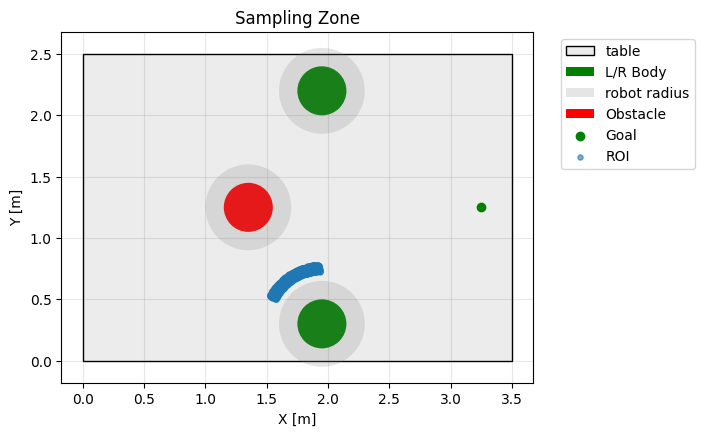

In [6]:
rng = np.random.default_rng(1)
behavior_mode, case_text = sample_case(rng)
print(f"Behavior mode: {behavior_mode}, text: {case_text}")
state_init, state_final = sample_init_target()
# plot_waypoint_distribution(behavior_mode, state_init=state_init, state_final=state_final,
#                                N=100, seed=42)
# plt.show()
plot_waypoint_distribution(behavior_mode = 2, state_init=state_init, state_final=state_final,
                               N=1000, seed=42)
plt.show()

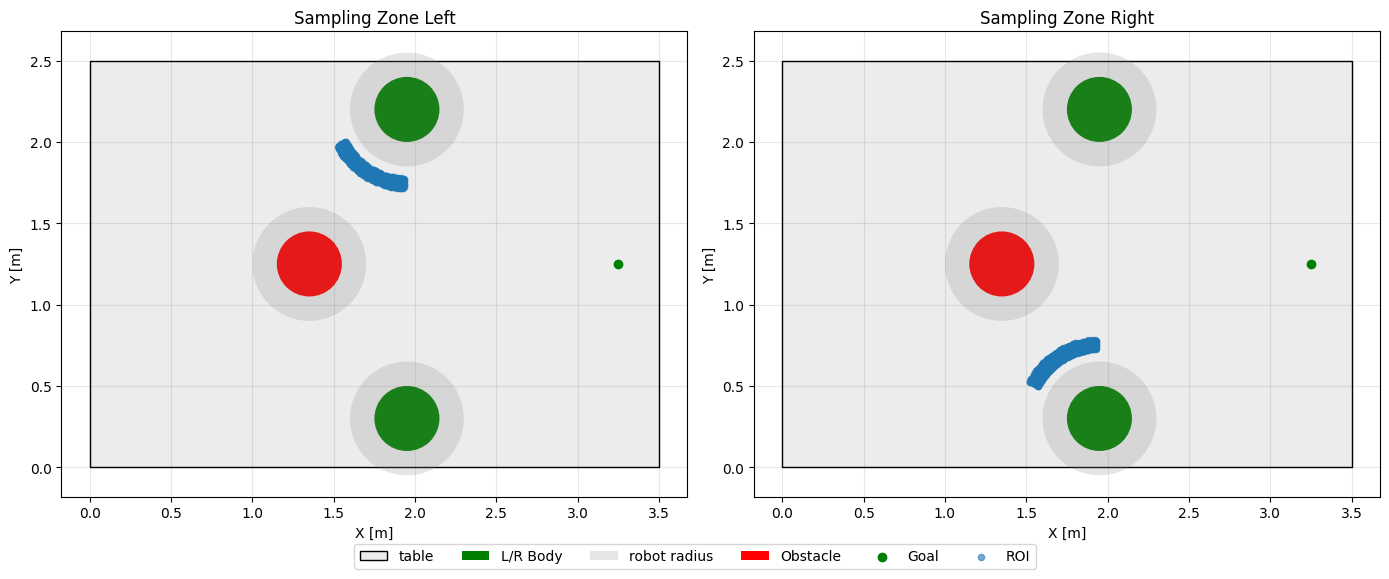

In [ ]:
def plot_waypoint_distribution_(behavior_mode, state_init, state_final,
                               N=1000, seed=None, show_sector=True,
                               ax=None):
    """
    Samples N waypoints using the given behavior_mode and plots them together
    using the same canvas style as plot_scenario_base.

    If `ax` is None, a new figure and axis are created.
    Otherwise, plotting is done on the provided axis.
    """
    rng = np.random.default_rng(seed)
    samples = []

    # Precompute sector center line for optional visualization
    body_idx = 0 if behavior_mode in {0, 1} else 2
    mid_idx  = 1
    c_body = ff.obs['position'][body_idx]
    c_mid  = ff.obs['position'][mid_idx]
    base_theta = np.arctan2((c_mid - c_body)[1], (c_mid - c_body)[0])

    # Decide whether to create a new fig/ax or reuse given one
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        created_fig = True
    else:
        fig = ax.figure

    # Draw background scenario
    plot_scenario_base(ax, state_init, state_final, ff.obs, ff.table, ff.robot_radius)

    # Sample
    for _ in range(N):
        wp = build_waypoint_for_obstacle(behavior_mode, rng=rng)
        if wp is None:
            continue
        samples.append(wp['pos'])

    if len(samples):
        pts = np.vstack(samples)
        ax.scatter(pts[:, 0], pts[:, 1],
                   s=80, alpha=0.6, marker='.', zorder=4, label='ROI')

    # Optional: draw the sector center ray for context
    if show_sector:
        r_body = ff.obs['radius'][body_idx]
        R0 = (r_body + ff.robot_radius) * ff.safety_margin + 0.03
        L  = R0 + 0.35
        a0 = base_theta - np.deg2rad(30.0)
        a1 = base_theta + np.deg2rad(30.0)

        # Example: just mark the body center (or leave rays commented as before)
        # p0 = c_body + R0 * np.array([np.cos(base_theta), np.sin(base_theta)])
        # p1 = c_body + L   * np.array([np.cos(base_theta), np.sin(base_theta)])
        # ax.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=1.5, zorder=3,
        #         label='Region of Interest (ROI)')
        # pb0 = c_body + L * np.array([np.cos(a0), np.sin(a0)])
        # pb1 = c_body + L * np.array([np.cos(a1), np.sin(a1)])
        pass  # keep your old commented lines if you want

    ax.set_title(f"Sampling Zone Left")
    ax.legend(bbox_to_anchor=(1.2, 1.0), loc='upper center', ncol=1)
    plt.tight_layout()

    return fig, ax

state_init, state_final = sample_init_target()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot behavior mode 1 ---
fig1, ax1 = plot_waypoint_distribution_(
    behavior_mode=1,
    state_init=state_init,
    state_final=state_final,
    N=1000,
    seed=42,
    show_sector=True,
    ax=axes[0]
)

plt.title("Samplin Zone Left")
# --- Plot behavior mode 2 ---
fig2, ax2 = plot_waypoint_distribution_(
    behavior_mode=2,
    state_init=state_init,
    state_final=state_final,
    N=1000,
    seed=43,
    show_sector=True,
    ax=axes[1]
)


# ---- Remove individual legends from subplots ----
axes[0].legend_.remove()
axes[1].legend_.remove()

# ---- Create combined legend (1 row, centered at bottom) ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           ncol=len(labels),
           bbox_to_anchor=(0.5, -0.02))
plt.title("Sampling Zone Right")

plt.tight_layout()
plt.show()


In [8]:
class Args:
    N = 30
    seed = 0
    outdir = root_folder / 'dataset' / 'quicktest10'

args = Args()

In [ ]:
rng = np.random.default_rng(args.seed)

# model
ff_model = FreeflyerModel()

# convenience
n_time_rpod = ff.n_time_rpod
T_full = ff.T
dt = ff.dt

ct = int(time.time())

for i in range(args.N):
    # sample case & waypoint & terminal index
    behavior_mode, case_text = sample_case(rng)
    k_T, k_wp = pick_terminal_index_and_wp_tidx(behavior_mode, rng)
    wp = None
    if behavior_mode in {0, 1}:
        wp = build_waypoint_for_obstacle(behavior_mode)
    elif behavior_mode in {2, 3}:
        wp = build_waypoint_for_obstacle(behavior_mode)
    if wp is not None and k_wp is not None:
        wp['t_index'] = int(k_wp)

    # problem instance
    state_init, state_final = sample_init_target()

    # warm-start (no obstacles) with the shorter horizon
    traj_cvx, J_cvx, it_cvx, feas_cvx = ocp_no_obstacle_avoidance(
        ff_model, state_init, state_final,
        n_time_override=k_T, waypoint=wp  # no waypoint in warm-start
    )

    if feas_cvx != 'optimal':
        print(f"[{i}] warm-start infeasible; skipping.")
        continue

    # SCP with obstacles (same horizon + waypoint if needed)
    traj_scp, J_scp, it_scp, feas_scp = ocp_obstacle_avoidance(
        ff_model,
        traj_cvx['states'][:, :k_T+1],
        traj_cvx['actions_G'][:, :k_T],
        state_init, state_final,
        n_time_override=k_T,
        waypoint=wp
    )

    if feas_scp != 'optimal':
        print(f"[{i}] SCP infeasible; skipping.")
        continue

    # Extract and pad to full horizon (time-major → already (S,dim) in your plotting convention)
    states_cvx_T    = traj_cvx['states'][:,:k_T].T          # (k_T, 6)
    actions_cvx_T   = traj_cvx['actions_G'][:,:k_T].T       # (k_T, 3)
    actions_t_cvx_T = traj_cvx['actions_t'][:,:k_T].T       # (k_T, C)

    states_scp_T    = traj_scp['states'][:,:k_T].T          # (k_T, 6)
    actions_scp_T   = traj_scp['actions_G'][:,:k_T].T       # (k_T, 3)
    actions_t_scp_T = traj_scp['actions_t'][:,:k_T].T       # (k_T, C)

    states_cvx_full, actions_cvx_full, actions_t_cvx_full = pad_to_full_horizon(
        states_cvx_T, actions_cvx_T, actions_t_cvx_T, k_T, n_time_rpod, hold_state=True
    )
    states_scp_full, actions_scp_full, actions_t_scp_full = pad_to_full_horizon(
        states_scp_T, actions_scp_T, actions_t_scp_T, k_T, n_time_rpod, hold_state=True
    )

    # plotting expects (dim,time); we transposed back:
    plot_title = f"[{i}] | tf={k_T}'"
    
    plot_trajectories(
        save_path=root_folder / args.outdir / f"case_{i:04d}_mode{behavior_mode}_tf{k_T}_{ct}.png",
        state_init=state_init,
        state_final=state_final,
        states_cvx=states_cvx_full,   # (T,6) positions in [:,0:2]
        states_scp=states_scp_full,
        obs=ff.obs,
        table=ff.table,
        robot_radius=ff.robot_radius,
        title=plot_title,
        wp=wp,
        k_wp=k_wp,
        show_plot=True
    )

    print(f"[{i}] SUCCESS  case={case_text:12s}  tf={k_T:3d} ")

print(f"\nDone")

# Plot candidate solutions

In [9]:
from optimization.ff_scenario import obs, robot_radius, table  # expects dict-like objects
def _plot_environment(ax):
    # Table
    ax.add_patch(
        Rectangle(
            (table['xy_low'][0], table['xy_low'][1]),
            table['xy_up'][0] - table['xy_low'][0],
            table['xy_up'][1] - table['xy_low'][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec='k',
            label='',
            zorder=2.5,
        )
    )

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = ''
        lab3 = '' if n == 0 else None
        lab2 = '' if n == 0 else None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='r',
                    ec='none',
                    label=lab1,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )
        else:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='g',
                    ec='none',
                    label=lab3,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X, m')
    # ax.set_ylabel('Y, m')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table['xy_low'][0], table['xy_up'][0])
    ax.set_ylim(table['xy_low'][1], table['xy_up'][1])

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Model and basic timing params
# ---------------------------------------------------
ff_model = FreeflyerModel()

n_time_rpod = ff.n_time_rpod
T_full      = ff.T
dt          = ff.dt

ct          = int(time.time())

n_behaviors = 6
CASE_NAMES = [
    "left_fast",   # 0
    "left_slow",   # 1
    "right_fast",  # 2
    "right_slow",  # 3
    "direct_fast", # 4
    "direct_slow"  # 5
]

# where to store ONE successful sample per behavior
samples = {b: None for b in range(n_behaviors)}

# ---------------------------------------------------
# Generate samples until we have one per behavior
# ---------------------------------------------------
for i in range(args.N):
    # stop early if all filled
    if all(samples[b] is not None for b in range(n_behaviors)):
        print(f"Collected one sample for each behavior by i={i}")
        break

    # sample case & behavior
    behavior_mode, case_text = sample_case(rng)

    # if we already have a sample for this mode, skip
    if samples[behavior_mode] is not None:
        continue

    # horizon + waypoint time index
    k_T, k_wp = pick_terminal_index_and_wp_tidx(behavior_mode, rng)

    # waypoint (only for obstacle-related modes)
    wp = None
    if behavior_mode in {0, 1, 2, 3}:
        wp = build_waypoint_for_obstacle(behavior_mode)
    if wp is not None and k_wp is not None:
        wp['t_index'] = int(k_wp)

    # initial and final states
    state_init, state_final = sample_init_target()

    # ---------------- warm-start (CVX, no obstacles) ----------------
    traj_cvx, J_cvx, it_cvx, feas_cvx = ocp_no_obstacle_avoidance(
        ff_model,
        state_init,
        state_final,
        n_time_override=k_T,
        waypoint=wp
    )

    if feas_cvx != 'optimal':
        print(f"[{i}] warm-start infeasible (behavior {behavior_mode}); skipping.")
        continue

    # ---------------- SCP with obstacles ----------------
    traj_scp, J_scp, it_scp, feas_scp = ocp_obstacle_avoidance(
        ff_model,
        traj_cvx['states'][:, :k_T+1],
        traj_cvx['actions_G'][:, :k_T],
        state_init,
        state_final,
        n_time_override=k_T,
        waypoint=wp
    )

    if feas_scp != 'optimal':
        print(f"[{i}] SCP infeasible (behavior {behavior_mode}); skipping.")
        continue

    # ---------------- Pad to full horizon (time-major) ----------------
    states_cvx_T    = traj_cvx['states'][:, :k_T].T        # (k_T, 6)
    actions_cvx_T   = traj_cvx['actions_G'][:, :k_T].T     # (k_T, 3)
    actions_t_cvx_T = traj_cvx['actions_t'][:, :k_T].T     # (k_T, C)

    states_scp_T    = traj_scp['states'][:, :k_T].T        # (k_T, 6)
    actions_scp_T   = traj_scp['actions_G'][:, :k_T].T     # (k_T, 3)
    actions_t_scp_T = traj_scp['actions_t'][:, :k_T].T     # (k_T, C)

    states_cvx_full, actions_cvx_full, actions_t_cvx_full = pad_to_full_horizon(
        states_cvx_T, actions_cvx_T, actions_t_cvx_T,
        k_T, n_time_rpod, hold_state=True
    )
    states_scp_full, actions_scp_full, actions_t_scp_full = pad_to_full_horizon(
        states_scp_T, actions_scp_T, actions_t_scp_T,
        k_T, n_time_rpod, hold_state=True
    )

    # store sample
    samples[behavior_mode] = dict(
        states_cvx=states_cvx_full,   # (T_full, 6)
        states_scp=states_scp_full,   # (T_full, 6)
        state_init=state_init,
        state_final=state_final,
        waypoint=wp,
        k_T=k_T,
        J_cvx=J_cvx,
        J_scp=J_scp,
        it_cvx=it_cvx,
        it_scp=it_scp,
    )

Collected one sample for each behavior by i=7


/tmp/ipykernel_2622373/1893849426.py:53: UserWarning: You passed a edgecolor/edgecolors ('purple') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(wx, wy,


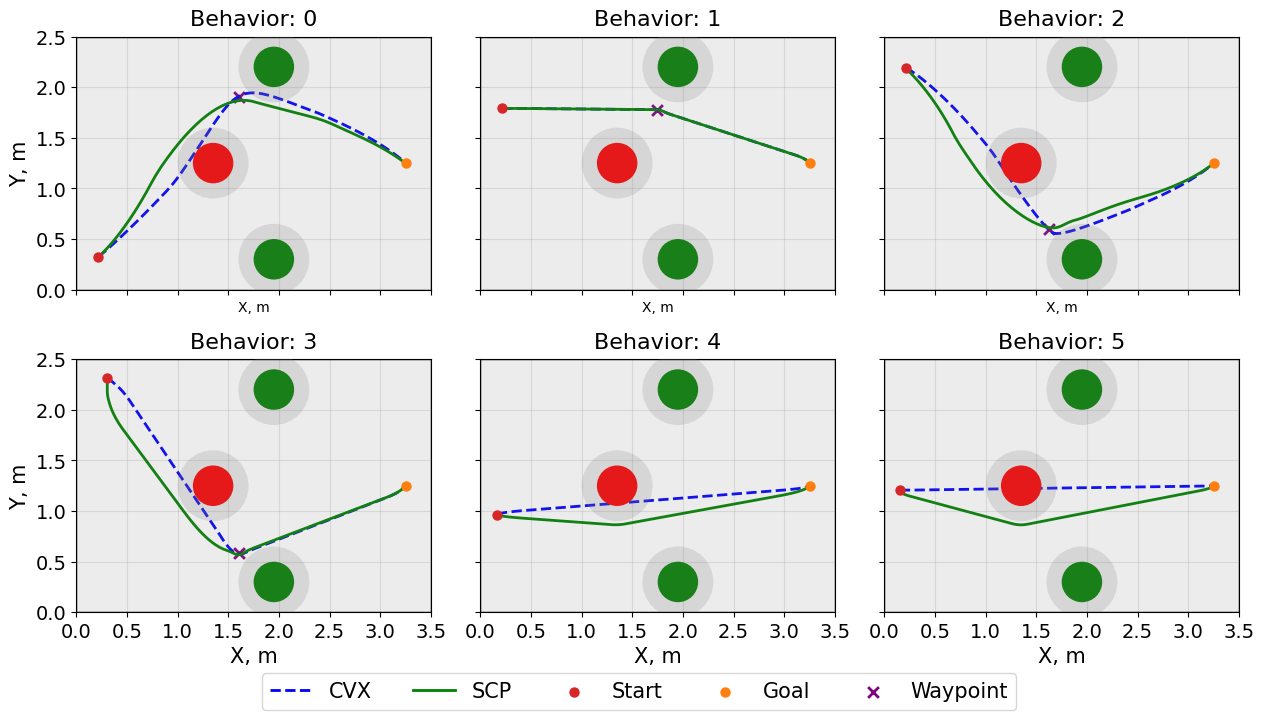

In [15]:
# Plot: 2x3 grid, one sample per behavior
# ---------------------------------------------------
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 15
TICK_FONTSIZE  = 14

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for b in range(n_behaviors):
    ax = axes[b]
    sample = samples[b]

    if sample is None:
        ax.text(0.5, 0.5, "No feasible sample",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{CASE_NAMES[b]} (none)", fontsize=TITLE_FONTSIZE)
        continue

    states_cvx = sample['states_cvx']   # (T_full, 6)
    states_scp = sample['states_scp']   # (T_full, 6)
    state_init = sample['state_init']
    state_final = sample['state_final']
    wp = sample['waypoint']

    # environment (box + obstacles)
    _plot_environment(ax)

    # positions: assume x = col 0, y = col 1
    x_cvx, y_cvx = states_cvx[:, 0], states_cvx[:, 1]
    x_scp, y_scp = states_scp[:, 0], states_scp[:, 1]

    # CVX (warm-start, dashed)
    ax.plot(x_cvx, y_cvx, '--', linewidth=2,
            color='blue', label='CVX')

    # SCP (with obstacles, solid)
    ax.plot(x_scp, y_scp, '-', linewidth=2,
            color='green', label='SCP')

    # Start & goal from SCP trajectory
    ax.scatter(x_scp[0], y_scp[0],
               s=30, marker='o', 
               color='tab:red', linewidth=2,
               label='Start' if b == 0 else None, zorder=8)
    ax.scatter(x_scp[-1], y_scp[-1],
               s=30, marker='o', 
               color='tab:orange', linewidth=2,
               label='Goal' if b == 0 else None, zorder=8)
    # Waypoint marker (if exists and has 'pos')
    if (wp is not None) and ('pos' in wp):
        wx, wy = wp['pos'][0], wp['pos'][1]
        ax.scatter(wx, wy,
                   s=60, marker='x',
                   facecolor='purple', edgecolor='purple',
                   linewidth=2,
                   label='Waypoint' if b == 0 else None)

    ax.set_title(f"Behavior: {b}", fontsize=TITLE_FONTSIZE, pad=8)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)

    if b % 3 == 0:
        ax.set_ylabel("Y, m", fontsize=LABEL_FONTSIZE)
    if b >= 3:
        ax.set_xlabel("X, m", fontsize=LABEL_FONTSIZE)
        ax.set_xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5])  # consistent x ticks

# one shared legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           ncol=len(labels),
           bbox_to_anchor=(0.5, 0.0),
           fontsize=LABEL_FONTSIZE)

plt.subplots_adjust(wspace=0.14, hspace=0.1)
# plt.tight_layout()
plt.savefig(f"ff_behav.png",dpi=600, bbox_inches='tight')
plt.show()